## DATA CLEANING AND PREPARATION 

In [0]:
## Uploading my dataset to pyspark

raw_df =spark.read.options(mode='FAILFAST', 
                              header = True, 
                              multiLine=True, 
                              inferSchema=True, 
                              escape='"').csv("/FileStore/tables/Employee_Attrition_Data__1_.csv")

 

display(raw_df)

Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [0]:
raw_df.printSchema()

root
 |-- Age: integer (nullable = true)
 |-- Attrition: string (nullable = true)
 |-- BusinessTravel: string (nullable = true)
 |-- DailyRate: integer (nullable = true)
 |-- Department: string (nullable = true)
 |-- DistanceFromHome: integer (nullable = true)
 |-- Education: integer (nullable = true)
 |-- EducationField: string (nullable = true)
 |-- EmployeeCount: integer (nullable = true)
 |-- EmployeeNumber: integer (nullable = true)
 |-- EnvironmentSatisfaction: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- HourlyRate: integer (nullable = true)
 |-- JobInvolvement: integer (nullable = true)
 |-- JobLevel: integer (nullable = true)
 |-- JobRole: string (nullable = true)
 |-- JobSatisfaction: integer (nullable = true)
 |-- MaritalStatus: string (nullable = true)
 |-- MonthlyIncome: integer (nullable = true)
 |-- MonthlyRate: integer (nullable = true)
 |-- NumCompaniesWorked: integer (nullable = true)
 |-- Over18: string (nullable = true)
 |-- OverTime: string 

In [0]:
## Filtering the dataset to the columns we want to make sense of for analysis

columnsToKeep = [ 
 "Age",
 "Department", 
 "DistanceFromHome",  
 "EnvironmentSatisfaction", 
 "Gender", 
 "JobInvolvement", 
 "JobSatisfaction", 
 "MaritalStatus", 
 "MonthlyIncome", 
 "OverTime",
 "PercentSalaryHike",
 "WorkLifeBalance", 
 "YearsAtCompany", 
 "YearsInCurrentRole", 
 "YearsSinceLastPromotion", 
 "YearsWithCurrManager",
 "Attrition"
 ]

#Displaying the filtered dataset AirBnb_df
employee_df = raw_df.select(columnsToKeep)
employee_df.cache().count()
display(employee_df)


Age,Department,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
41,Sales,1,2,Female,3,4,Single,5993,Yes,11,1,6,4,0,5,Yes
49,Research & Development,8,3,Male,2,2,Married,5130,No,23,3,10,7,1,7,No
37,Research & Development,2,4,Male,2,3,Single,2090,Yes,15,3,0,0,0,0,Yes
33,Research & Development,3,4,Female,3,3,Married,2909,Yes,11,3,8,7,3,0,No
27,Research & Development,2,1,Male,3,2,Married,3468,No,12,3,2,2,2,2,No
32,Research & Development,2,4,Male,3,4,Single,3068,No,13,2,7,7,3,6,No
59,Research & Development,3,3,Female,4,1,Married,2670,Yes,20,2,1,0,0,0,No
30,Research & Development,24,4,Male,3,3,Divorced,2693,No,22,3,1,0,0,0,No
38,Research & Development,23,4,Male,2,3,Single,9526,No,21,3,9,7,1,8,No
36,Research & Development,27,3,Male,3,3,Married,5237,No,13,2,7,7,7,7,No


# Checking for Null Values 

In [0]:
#Y label has no nulls  -- no imputations is required here -- we can aim to convert

null_count = employee_df.filter(employee_df.Attrition.isNull()).count()
print(f"Number of null values in 'Attrition' column: {null_count}")

Number of null values in 'Attrition' column: 0


In [0]:
from pyspark.sql.functions import col, isnan, when, count
 
# Count null or NaN values for each column
null_counts = employee_df.select(
    [count(when(col(c).isNull() | isnan(col(c)), c)).alias(c) for c in employee_df.columns]
)
 
# Show the null counts for each column
display(null_counts)

Age,Department,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


We see that the column Job Involment containts missing values - let's look into the dataset to find more! 

In [0]:
#DATA IMPUTATION ON THE FEATURE JOB INVOLVEMENT

null_count = employee_df.filter(employee_df.JobInvolvement.isNull()).count()
print(f"Number of null values in 'JobInvolvement' column: {null_count}")

Number of null values in 'JobInvolvement' column: 0


## Data Imputation on NULL VALUES - Job Involvement

In [0]:
## Step 1 : Importing the required packages

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, mean, when, count
import seaborn as sns
import matplotlib.pyplot as plt

In [0]:
## Checking for patterns in the dataset to impute the data 

pandas_df = employee_df.toPandas()

/root/.ipykernel/969/command-4304932023644412-606071015:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(pandas_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")


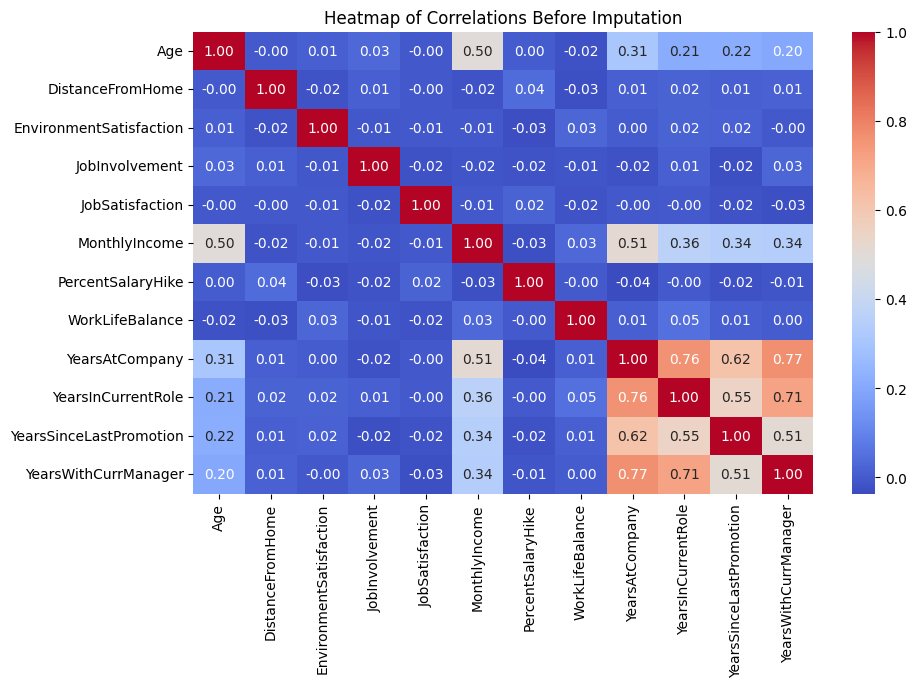

In [0]:
plt.figure(figsize=(10, 6))
sns.heatmap(pandas_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of Correlations Before Imputation")
plt.show()

In [0]:
## Dispaly the dataframe with only the Null values 
Null_JobInvl_df = employee_df.filter(col("JobInvolvement").isNull())

## Select relevant columns: 'beds', 'Age', and 'YearsWithCurrManager'
filtered_df = Null_JobInvl_df .select("JobInvolvement", "Age", "YearsWithCurrManager")

##  Display the filtered dataset
display(filtered_df)

JobInvolvement,Age,YearsWithCurrManager


In [0]:
from pyspark.sql.functions import col

# Filter rows where 'beds' is not null
non_null_df = employee_df.filter(col("JobInvolvement").isNotNull())

# Select relevant columns: 'beds', 'Age', and 'YearsWithCurrManager'
filtered_non_null_df = non_null_df.select("JobInvolvement", "Age", "YearsWithCurrManager")

# Display the filtered dataset
display(filtered_non_null_df.show(20))


+--------------+---+--------------------+
|JobInvolvement|Age|YearsWithCurrManager|
+--------------+---+--------------------+
|             3| 41|                   5|
|             2| 49|                   7|
|             2| 37|                   0|
|             3| 33|                   0|
|             3| 27|                   2|
|             3| 32|                   6|
|             4| 59|                   0|
|             3| 30|                   0|
|             2| 38|                   8|
|             3| 36|                   7|
|             4| 35|                   3|
|             2| 29|                   8|
|             3| 31|                   3|
|             3| 34|                   2|
|             2| 28|                   3|
|             4| 29|                   8|
|             4| 32|                   5|
|             4| 22|                   0|
|             2| 53|                   7|
|             3| 38|                   2|
+--------------+---+--------------

In [0]:
# Step 2: Impute missing values with mean - 
mean_value = employee_df.select(mean(col("JobInvolvement"))).collect()[0][0]
imputed_df = employee_df.fillna({"JobInvolvement": mean_value})

In [0]:
pandas_df = imputed_df.toPandas()

/root/.ipykernel/969/command-4304932023644417-445263768:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(pandas_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")


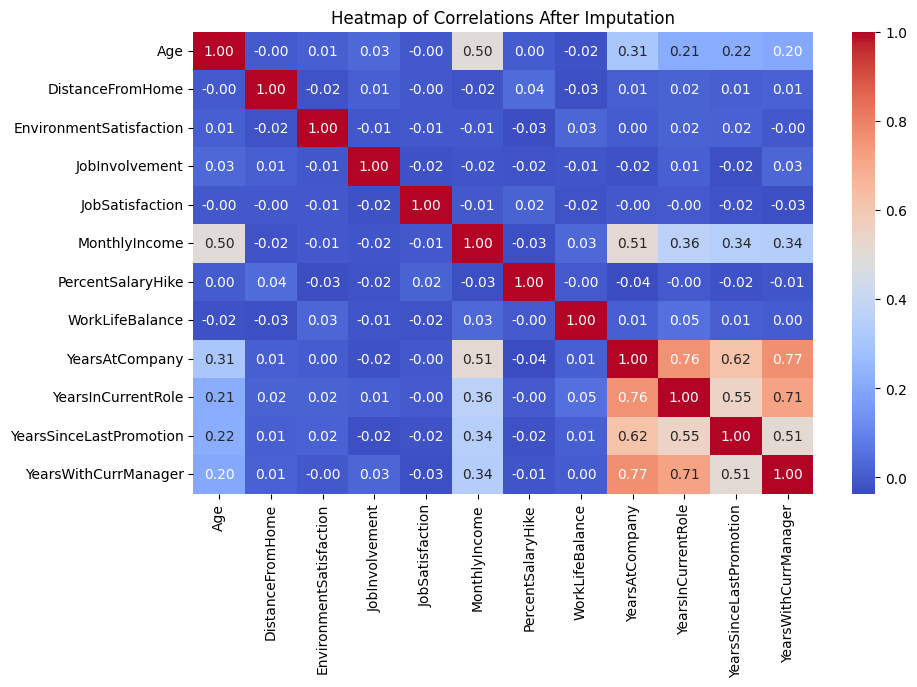

In [0]:
# Step 4: Visualize patterns using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pandas_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap of Correlations After Imputation")
plt.show()

The above heat map suggests that our pattern of sorts between **Job Involvement** and **AGE and Years with Current Manager** is not lost. Hence, we can use the mean imputation as a justified one for our dataset.

- No Bias will be concured with data imputation.
- No accuary will be incured while using this mechanism.

In [0]:
## Dispaly the dataframe with only the Null values 
Null_JobInvl_df = imputed_df.filter(col("JobInvolvement").isNull())

# Show the rows with empty values in Job Involvement
display(Null_JobInvl_df)  ## 25 records


Age,Department,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition


Missing values are handled! 

In [0]:
employee_df = imputed_df

In [0]:
from pyspark.sql.functions import col, isnan, when, count
 
# Count null or NaN values for each column
null_counts = employee_df.select(
    [count(when(col(c).isNull() | isnan(col(c)), c)).alias(c) for c in employee_df.columns]
)
 
# Show the null counts for each column
display(null_counts)

Age,Department,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Outliers Analysis 

We are checking for outliers/abnormalities in our dataset using functions in pyspark.

In [0]:
from pyspark.sql.functions import col, count
 
# Function to detect outliers in a single column
def detect_outliers(employee_df, column):
    # Calculate Q1, Q3, and IQR
    Q1, Q3 = employee_df.approxQuantile(column, [0.25, 0.75], 0.0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Count outliers
    outliers = employee_df.filter((col(column) < lower_bound) | (col(column) > upper_bound))
    return outliers.count()
 
# List of numeric columns to check
numeric_columns = [col_name for col_name, dtype in employee_df.dtypes if dtype in ("int", "double")]
 
# Check for outliers in each numeric column
for column in numeric_columns:
    outlier_count = detect_outliers(employee_df, column)
    print(f"Column '{column}' has {outlier_count} outliers.")

Column 'Age' has 0 outliers.
Column 'DistanceFromHome' has 0 outliers.
Column 'EnvironmentSatisfaction' has 0 outliers.
Column 'JobInvolvement' has 0 outliers.
Column 'JobSatisfaction' has 0 outliers.
Column 'MonthlyIncome' has 114 outliers.
Column 'PercentSalaryHike' has 0 outliers.
Column 'WorkLifeBalance' has 0 outliers.
Column 'YearsAtCompany' has 104 outliers.
Column 'YearsInCurrentRole' has 21 outliers.
Column 'YearsSinceLastPromotion' has 107 outliers.
Column 'YearsWithCurrManager' has 14 outliers.


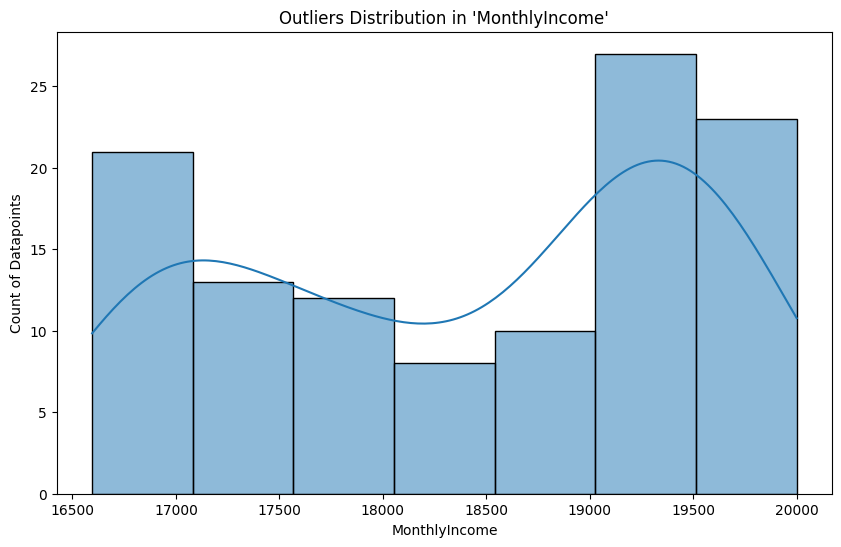

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

# Function to detect outliers in a single column
def detect_outliers(employee_df, column):
    # Calculate Q1, Q3, and IQR
    Q1, Q3 = employee_df.approxQuantile(column, [0.25, 0.75], 0.0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filter outliers
    outliers = employee_df.filter((col(column) < lower_bound) | (col(column) > upper_bound))
    return outliers

# Manually specify the column you want to visualize (e.g., 'beds')
column_to_visualize = "MonthlyIncome"  # Replace with your column of interest

# Check if the column exists in the DataFrame
if column_to_visualize in [col_name for col_name, dtype in employee_df.dtypes if dtype in ("int", "double")]:
    # Detect outliers for the specified column
    outliers_df = detect_outliers(employee_df, column_to_visualize)
    
    # Convert outliers DataFrame to Pandas for visualization
    outliers_pandas_df = outliers_df.select(column_to_visualize).toPandas()
    
    # Skip visualization if no outliers are detected
    if outliers_pandas_df.empty:
        print(f"No outliers detected in column '{column_to_visualize}'.")
    else:
        # Visualize the outliers using a histogram
        plt.figure(figsize=(10, 6))
        sns.histplot(outliers_pandas_df[column_to_visualize], kde=True, bins=7)  # 'bins' controls the number of histogram bars
        plt.title(f"Outliers Distribution in '{column_to_visualize}'")
        plt.xlabel(column_to_visualize)
        plt.ylabel('Count of Datapoints')
        plt.show()
else:
    print(f"Column '{column_to_visualize}' not found in the dataset.")


We see **two peaks** : between **16500 - 17000**  and **19000 - 19500 **

And cannot be viewed as normal distribution

But the intresting fact is that, although, we have max outliners for employee's monthly income - we are not gonna handle it coz this is valuable information and handling this will lead to loss of data.

We will be applying scaling to handle the outliers here such that we don't loose the data.

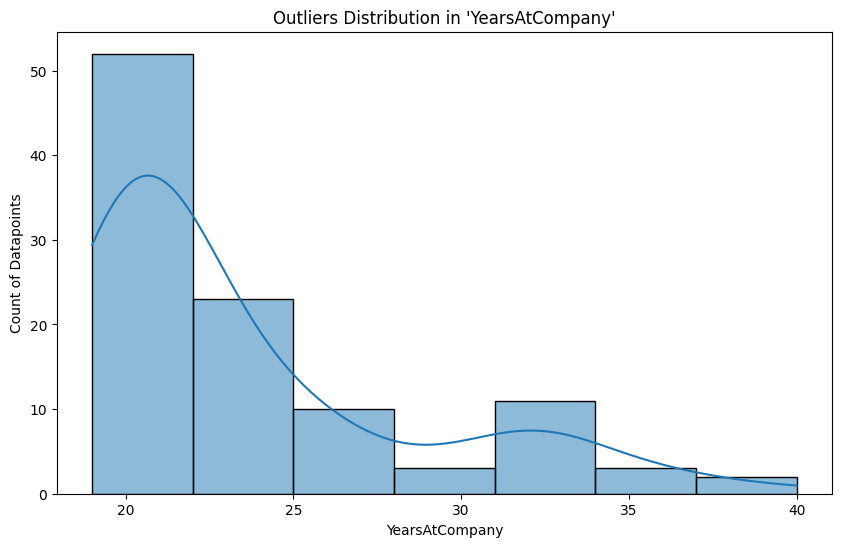

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

# Function to detect outliers in a single column
def detect_outliers(employee_df, column):
    # Calculate Q1, Q3, and IQR
    Q1, Q3 = employee_df.approxQuantile(column, [0.25, 0.75], 0.0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Filter outliers
    outliers = employee_df.filter((col(column) < lower_bound) | (col(column) > upper_bound))
    return outliers

# Manually specify the column you want to visualize (e.g., 'beds')
column_to_visualize = "YearsAtCompany"  # Replace with your column of interest

# Check if the column exists in the DataFrame
if column_to_visualize in [col_name for col_name, dtype in employee_df.dtypes if dtype in ("int", "double")]:
    # Detect outliers for the specified column
    outliers_df = detect_outliers(employee_df, column_to_visualize)
    
    # Convert outliers DataFrame to Pandas for visualization
    outliers_pandas_df = outliers_df.select(column_to_visualize).toPandas()
    
    # Skip visualization if no outliers are detected
    if outliers_pandas_df.empty:
        print(f"No outliers detected in column '{column_to_visualize}'.")
    else:
        # Visualize the outliers using a histogram
        plt.figure(figsize=(10, 6))
        sns.histplot(outliers_pandas_df[column_to_visualize], kde=True, bins=7)  # 'bins' controls the number of histogram bars
        plt.title(f"Outliers Distribution in '{column_to_visualize}'")
        plt.xlabel(column_to_visualize)
        plt.ylabel('Count of Datapoints')
        plt.show()
else:
    print(f"Column '{column_to_visualize}' not found in the dataset.")


It is rightly skewed - and based on reality of the data collection - we will not impute it but scale it to reason out these valid datapoints.

In [0]:
display(employee_df.printSchema())

root
 |-- Age: integer (nullable = true)
 |-- Department: string (nullable = true)
 |-- DistanceFromHome: integer (nullable = true)
 |-- EnvironmentSatisfaction: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- JobInvolvement: integer (nullable = true)
 |-- JobSatisfaction: integer (nullable = true)
 |-- MaritalStatus: string (nullable = true)
 |-- MonthlyIncome: integer (nullable = true)
 |-- OverTime: string (nullable = true)
 |-- PercentSalaryHike: integer (nullable = true)
 |-- WorkLifeBalance: integer (nullable = true)
 |-- YearsAtCompany: integer (nullable = true)
 |-- YearsInCurrentRole: integer (nullable = true)
 |-- YearsSinceLastPromotion: integer (nullable = true)
 |-- YearsWithCurrManager: integer (nullable = true)
 |-- Attrition: string (nullable = true)



## Data Conversion and Preparation 

Columns with **strings** in our dataset are : **Department**, **Job Role** , **Gender**, **Marital status**, **Over Time**, **Attrition**

In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

# Step 1: Use StringIndexer to convert the 'Department' column to numeric indices
indexer = StringIndexer(inputCol="Department", outputCol="Department_index")

# Step 2: Use OneHotEncoder to convert the numeric indices into one-hot encoded vectors
encoder = OneHotEncoder(inputCol="Department_index", outputCol="Department_onehot")

# Step 3: Create a pipeline to apply both transformations
pipeline = Pipeline(stages=[indexer, encoder])

# Step 4: Apply the pipeline to the DataFrame
encoded_df = pipeline.fit(employee_df).transform(employee_df)

# Step 5: Convert the OneHotEncoded vector column into separate columns (manually)
encoded_df = encoded_df.withColumn("Sales", F.when(F.col("Department_index") == 0, 1).otherwise(0)) \
                       .withColumn("Research_and_Development", F.when(F.col("Department_index") == 1, 1).otherwise(0)) \
                       .withColumn("Human_Resources", F.when(F.col("Department_index") == 2, 1).otherwise(0))

# Step 6: Show the result with 0 and 1 columns for each department
display(encoded_df)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Age,Department,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Department_index,Department_onehot,Sales,Research_and_Development,Human_Resources
41,Sales,1,2,Female,3,4,Single,5993,Yes,11,1,6,4,0,5,Yes,1.0,"Map(vectorType -> sparse, length -> 2, indices -> List(1), values -> List(1.0))",0,1,0
49,Research & Development,8,3,Male,2,2,Married,5130,No,23,3,10,7,1,7,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
37,Research & Development,2,4,Male,2,3,Single,2090,Yes,15,3,0,0,0,0,Yes,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
33,Research & Development,3,4,Female,3,3,Married,2909,Yes,11,3,8,7,3,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
27,Research & Development,2,1,Male,3,2,Married,3468,No,12,3,2,2,2,2,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
32,Research & Development,2,4,Male,3,4,Single,3068,No,13,2,7,7,3,6,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
59,Research & Development,3,3,Female,4,1,Married,2670,Yes,20,2,1,0,0,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
30,Research & Development,24,4,Male,3,3,Divorced,2693,No,22,3,1,0,0,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
38,Research & Development,23,4,Male,2,3,Single,9526,No,21,3,9,7,1,8,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
36,Research & Development,27,3,Male,3,3,Married,5237,No,13,2,7,7,7,7,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0


In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

# Step 1: Use StringIndexer to convert the 'Gender' column to numeric indices
indexer_gender = StringIndexer(inputCol="Gender", outputCol="Gender_index")

# Step 2: Use OneHotEncoder to convert the numeric indices into one-hot encoded vectors
encoder_gender = OneHotEncoder(inputCol="Gender_index", outputCol="Gender_onehot")

# Step 3: Create a pipeline to apply both transformations
pipeline_gender = Pipeline(stages=[indexer_gender, encoder_gender])

# Step 4: Apply the pipeline to the DataFrame
encoded_gender_df = pipeline_gender.fit(encoded_df).transform(encoded_df)

# Step 5: Convert the OneHotEncoded vector column into separate columns (manually)
encoded_gender_df = encoded_gender_df.withColumn("Female", F.when(F.col("Gender_index") == 0, 1).otherwise(0)) \
                                     .withColumn("Male", F.when(F.col("Gender_index") == 1, 1).otherwise(0))

# Step 6: Show the result with 0 and 1 columns for each gender
display(encoded_gender_df)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Age,Department,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Department_index,Department_onehot,Sales,Research_and_Development,Human_Resources,Gender_index,Gender_onehot,Female,Male
41,Sales,1,2,Female,3,4,Single,5993,Yes,11,1,6,4,0,5,Yes,1.0,"Map(vectorType -> sparse, length -> 2, indices -> List(1), values -> List(1.0))",0,1,0,1.0,"Map(vectorType -> sparse, length -> 1, indices -> List(), values -> List())",0,1
49,Research & Development,8,3,Male,2,2,Married,5130,No,23,3,10,7,1,7,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0
37,Research & Development,2,4,Male,2,3,Single,2090,Yes,15,3,0,0,0,0,Yes,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0
33,Research & Development,3,4,Female,3,3,Married,2909,Yes,11,3,8,7,3,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,1.0,"Map(vectorType -> sparse, length -> 1, indices -> List(), values -> List())",0,1
27,Research & Development,2,1,Male,3,2,Married,3468,No,12,3,2,2,2,2,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0
32,Research & Development,2,4,Male,3,4,Single,3068,No,13,2,7,7,3,6,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0
59,Research & Development,3,3,Female,4,1,Married,2670,Yes,20,2,1,0,0,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,1.0,"Map(vectorType -> sparse, length -> 1, indices -> List(), values -> List())",0,1
30,Research & Development,24,4,Male,3,3,Divorced,2693,No,22,3,1,0,0,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0
38,Research & Development,23,4,Male,2,3,Single,9526,No,21,3,9,7,1,8,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0
36,Research & Development,27,3,Male,3,3,Married,5237,No,13,2,7,7,7,7,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0


In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

# Step 1: Use StringIndexer to convert the 'Marital Status' column to numeric indices
indexer_MaritalStatus = StringIndexer(inputCol="MaritalStatus", outputCol="MaritalStatus_index")

# Step 2: Use OneHotEncoder to convert the numeric indices into one-hot encoded vectors
encoder_MaritalStatus = OneHotEncoder(inputCol="MaritalStatus_index", outputCol="MaritalStatus_onehot")

# Step 3: Create a pipeline to apply both transformations
pipeline_MaritalStatus = Pipeline(stages=[indexer_MaritalStatus, encoder_MaritalStatus])

# Step 4: Apply the pipeline to the DataFrame
encoded_MaritalStatus_df = pipeline_MaritalStatus.fit(encoded_gender_df).transform(encoded_gender_df)

# Step 5: Convert the OneHotEncoded vector column into separate columns (manually)
encoded_MaritalStatus_df = encoded_MaritalStatus_df.withColumn("Single", F.when(F.col("MaritalStatus_index") == 0, 1).otherwise(0)) \
                       .withColumn("Married", F.when(F.col("MaritalStatus_index") == 1, 1).otherwise(0)) \
                       .withColumn("Divorced", F.when(F.col("MaritalStatus_index") == 2, 1).otherwise(0))

# Step 6: Show the result with 0 and 1 columns for each gender
display(encoded_MaritalStatus_df)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Age,Department,DistanceFromHome,EnvironmentSatisfaction,Gender,JobInvolvement,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Department_index,Department_onehot,Sales,Research_and_Development,Human_Resources,Gender_index,Gender_onehot,Female,Male,MaritalStatus_index,MaritalStatus_onehot,Single,Married,Divorced
41,Sales,1,2,Female,3,4,Single,5993,Yes,11,1,6,4,0,5,Yes,1.0,"Map(vectorType -> sparse, length -> 2, indices -> List(1), values -> List(1.0))",0,1,0,1.0,"Map(vectorType -> sparse, length -> 1, indices -> List(), values -> List())",0,1,1.0,"Map(vectorType -> sparse, length -> 2, indices -> List(1), values -> List(1.0))",0,1,0
49,Research & Development,8,3,Male,2,2,Married,5130,No,23,3,10,7,1,7,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
37,Research & Development,2,4,Male,2,3,Single,2090,Yes,15,3,0,0,0,0,Yes,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0,1.0,"Map(vectorType -> sparse, length -> 2, indices -> List(1), values -> List(1.0))",0,1,0
33,Research & Development,3,4,Female,3,3,Married,2909,Yes,11,3,8,7,3,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,1.0,"Map(vectorType -> sparse, length -> 1, indices -> List(), values -> List())",0,1,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
27,Research & Development,2,1,Male,3,2,Married,3468,No,12,3,2,2,2,2,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
32,Research & Development,2,4,Male,3,4,Single,3068,No,13,2,7,7,3,6,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0,1.0,"Map(vectorType -> sparse, length -> 2, indices -> List(1), values -> List(1.0))",0,1,0
59,Research & Development,3,3,Female,4,1,Married,2670,Yes,20,2,1,0,0,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,1.0,"Map(vectorType -> sparse, length -> 1, indices -> List(), values -> List())",0,1,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0
30,Research & Development,24,4,Male,3,3,Divorced,2693,No,22,3,1,0,0,0,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0,2.0,"Map(vectorType -> sparse, length -> 2, indices -> List(), values -> List())",0,0,1
38,Research & Development,23,4,Male,2,3,Single,9526,No,21,3,9,7,1,8,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0,1.0,"Map(vectorType -> sparse, length -> 2, indices -> List(1), values -> List(1.0))",0,1,0
36,Research & Development,27,3,Male,3,3,Married,5237,No,13,2,7,7,7,7,No,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0,0.0,"Map(vectorType -> sparse, length -> 1, indices -> List(0), values -> List(1.0))",1,0,0.0,"Map(vectorType -> sparse, length -> 2, indices -> List(0), values -> List(1.0))",1,0,0


In [0]:
encoded_MaritalStatus_df.printSchema()

root
 |-- Age: integer (nullable = true)
 |-- Department: string (nullable = true)
 |-- DistanceFromHome: integer (nullable = true)
 |-- EnvironmentSatisfaction: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- JobInvolvement: integer (nullable = true)
 |-- JobSatisfaction: integer (nullable = true)
 |-- MaritalStatus: string (nullable = true)
 |-- MonthlyIncome: integer (nullable = true)
 |-- OverTime: string (nullable = true)
 |-- PercentSalaryHike: integer (nullable = true)
 |-- WorkLifeBalance: integer (nullable = true)
 |-- YearsAtCompany: integer (nullable = true)
 |-- YearsInCurrentRole: integer (nullable = true)
 |-- YearsSinceLastPromotion: integer (nullable = true)
 |-- YearsWithCurrManager: integer (nullable = true)
 |-- Attrition: string (nullable = true)
 |-- Department_index: double (nullable = false)
 |-- Department_onehot: vector (nullable = true)
 |-- Sales: integer (nullable = false)
 |-- Research_and_Development: integer (nullable = false)
 |-- Hu

In [0]:
# List of columns to drop
columns_to_drop = ["Department_index", "Department_onehot", "Department", "MaritalStatus_onehot", "MaritalStatus_index", "MaritalStatus", "Gender_index", "Gender_onehot", "Gender"]  # Replace with your column names

# Drop the specified columns from the DataFrame
encoded_df = encoded_MaritalStatus_df.drop(*columns_to_drop)

# Show the DataFrame after dropping the columns
encoded_df.printSchema()


root
 |-- Age: integer (nullable = true)
 |-- DistanceFromHome: integer (nullable = true)
 |-- EnvironmentSatisfaction: integer (nullable = true)
 |-- JobInvolvement: integer (nullable = true)
 |-- JobSatisfaction: integer (nullable = true)
 |-- MonthlyIncome: integer (nullable = true)
 |-- OverTime: string (nullable = true)
 |-- PercentSalaryHike: integer (nullable = true)
 |-- WorkLifeBalance: integer (nullable = true)
 |-- YearsAtCompany: integer (nullable = true)
 |-- YearsInCurrentRole: integer (nullable = true)
 |-- YearsSinceLastPromotion: integer (nullable = true)
 |-- YearsWithCurrManager: integer (nullable = true)
 |-- Attrition: string (nullable = true)
 |-- Sales: integer (nullable = false)
 |-- Research_and_Development: integer (nullable = false)
 |-- Human_Resources: integer (nullable = false)
 |-- Female: integer (nullable = false)
 |-- Male: integer (nullable = false)
 |-- Single: integer (nullable = false)
 |-- Married: integer (nullable = false)
 |-- Divorced: integer

Post one-hot encoding, we have few more string values left - which we will map - as it's ordinal data or TRUE or FALSE like data.

In [0]:
from pyspark.sql.functions import when, col, trim, lower

# Define mappings for string columns
overtime_mapping = {
    "yes": 1,
    "no": 0
}

attrition_mapping = {
    "yes": 1,
    "no": 0
}

# JobInvolvement needs mapping, define its mapping
job_involvement_mapping = {
    "low": 0,
    "medium": 1,
    "high": 2,
    "very high": 3
}


# Generic function to map string values to integers
def map_column(df, column, mapping):
    df = df.withColumn(column, trim(lower(col(column)))) # Clean the column
    for key, value in mapping.items():
        df = df.withColumn(column, when(col(column) == key, value).otherwise(col(column)))
    df = df.withColumn(column, col(column).cast("int")) # Cast to integer
    return df

# Apply mappings to columns
encoded_df = map_column(encoded_df, "OverTime", overtime_mapping)
encoded_df = map_column(encoded_df, "Attrition", attrition_mapping)
encoded_df = map_column(encoded_df, "JobInvolvement", job_involvement_mapping)

# Show the schema to verify changes
encoded_df.printSchema()

root
 |-- Age: integer (nullable = true)
 |-- DistanceFromHome: integer (nullable = true)
 |-- EnvironmentSatisfaction: integer (nullable = true)
 |-- JobInvolvement: integer (nullable = true)
 |-- JobSatisfaction: integer (nullable = true)
 |-- MonthlyIncome: integer (nullable = true)
 |-- OverTime: integer (nullable = true)
 |-- PercentSalaryHike: integer (nullable = true)
 |-- WorkLifeBalance: integer (nullable = true)
 |-- YearsAtCompany: integer (nullable = true)
 |-- YearsInCurrentRole: integer (nullable = true)
 |-- YearsSinceLastPromotion: integer (nullable = true)
 |-- YearsWithCurrManager: integer (nullable = true)
 |-- Attrition: integer (nullable = true)
 |-- Sales: integer (nullable = false)
 |-- Research_and_Development: integer (nullable = false)
 |-- Human_Resources: integer (nullable = false)
 |-- Female: integer (nullable = false)
 |-- Male: integer (nullable = false)
 |-- Single: integer (nullable = false)
 |-- Married: integer (nullable = false)
 |-- Divorced: integ

In [0]:
display(encoded_df)



Age,DistanceFromHome,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,OverTime,PercentSalaryHike,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Sales,Research_and_Development,Human_Resources,Female,Male,Single,Married,Divorced
41,1,2,3,4,5993,1,11,1,6,4,0,5,1,0,1,0,0,1,0,1,0
49,8,3,2,2,5130,0,23,3,10,7,1,7,0,1,0,0,1,0,1,0,0
37,2,4,2,3,2090,1,15,3,0,0,0,0,1,1,0,0,1,0,0,1,0
33,3,4,3,3,2909,1,11,3,8,7,3,0,0,1,0,0,0,1,1,0,0
27,2,1,3,2,3468,0,12,3,2,2,2,2,0,1,0,0,1,0,1,0,0
32,2,4,3,4,3068,0,13,2,7,7,3,6,0,1,0,0,1,0,0,1,0
59,3,3,4,1,2670,1,20,2,1,0,0,0,0,1,0,0,0,1,1,0,0
30,24,4,3,3,2693,0,22,3,1,0,0,0,0,1,0,0,1,0,0,0,1
38,23,4,2,3,9526,0,21,3,9,7,1,8,0,1,0,0,1,0,0,1,0
36,27,3,3,3,5237,0,13,2,7,7,7,7,0,1,0,0,1,0,1,0,0


# STATS ANALYSIS

In [0]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

data = encoded_df

# Preview the data
data.show(5)
data.printSchema()

# Assemble features into a single vector
feature_columns = [col for col in data.columns if col != "Attrition"]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="raw_features")
data = assembler.transform(data)

# Scale the features using StandardScaler
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(data)
data = scaler_model.transform(data).select("features", "Attrition")

# Split the dataset into training and testing
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

# Train Logistic Regression model
lr = LogisticRegression(labelCol="Attrition", featuresCol="features")
lr_model = lr.fit(train_data)

# Make predictions
predictions = lr_model.transform(test_data)
predictions.select("Attrition", "prediction", "probability").show(5)

# Evaluate the model
evaluator = MulticlassClassificationEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {accuracy:.2f}")

# Create a confusion matrix
confusion_matrix = predictions.groupBy("Attrition", "prediction").count().withColumnRenamed("count", "frequency")
confusion_matrix.show()


+---+----------------+-----------------------+--------------+---------------+-------------+--------+-----------------+---------------+--------------+------------------+-----------------------+--------------------+---------+-----+------------------------+---------------+------+----+------+-------+--------+
|Age|DistanceFromHome|EnvironmentSatisfaction|JobInvolvement|JobSatisfaction|MonthlyIncome|OverTime|PercentSalaryHike|WorkLifeBalance|YearsAtCompany|YearsInCurrentRole|YearsSinceLastPromotion|YearsWithCurrManager|Attrition|Sales|Research_and_Development|Human_Resources|Female|Male|Single|Married|Divorced|
+---+----------------+-----------------------+--------------+---------------+-------------+--------+-----------------+---------------+--------------+------------------+-----------------------+--------------------+---------+-----+------------------------+---------------+------+----+------+-------+--------+
| 41|               1|                      2|             3|              4|  

Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

+---------+----------+--------------------+
|Attrition|prediction|         probability|
+---------+----------+--------------------+
|        1|       0.0|[0.75755579716464...|
|        0|       0.0|[0.55837574811775...|
|        1|       1.0|[0.41218055189308...|
|        1|       1.0|[0.24474563731515...|
|        0|       0.0|[0.74504009865612...|
+---------+----------+--------------------+
only showing top 5 rows

Accuracy: 0.86
+---------+----------+---------+
|Attrition|prediction|frequency|
+---------+----------+---------+
|        1|       0.0|       27|
|        0|       0.0|      205|
|        1|       1.0|       13|
|        0|       1.0|        9|
+---------+----------+---------+



Insights
True Positives (TP): 13 cases where Attrition is 1 and was predicted correctly as 1.
True Negatives (TN): 205 cases where Attrition is 0 and was predicted correctly as 0.
False Positives (FP): 10 cases where Attrition is 0 but was incorrectly predicted as 1.
False Negatives (FN): 26 cases where Attrition is 1 but was incorrectly predicted as 0.


In [0]:
from pyspark.sql import functions as F

# Calculate confusion matrix values
tp = predictions.filter((F.col("Attrition") == 1) & (F.col("prediction") == 1)).count()
tn = predictions.filter((F.col("Attrition") == 0) & (F.col("prediction") == 0)).count()
fp = predictions.filter((F.col("Attrition") == 0) & (F.col("prediction") == 1)).count()
fn = predictions.filter((F.col("Attrition") == 1) & (F.col("prediction") == 0)).count()

# Print confusion matrix
print("Confusion Matrix:")
print(f"                Predicted 0     Predicted 1")
print(f"Actual 0       {tn}              {fp}")
print(f"Actual 1       {fn}              {tp}")


Confusion Matrix:
                Predicted 0     Predicted 1
Actual 0       205              9
Actual 1       27              13


Let us do the Classification Models

In [0]:
from pyspark.ml.classification import RandomForestClassifier, DecisionTreeClassifier, LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml.feature import VectorAssembler


In [0]:


dt_decision = DecisionTreeClassifier(labelCol="Attrition", featuresCol="features")
dt_decision_model = dt_decision.fit(train_data)
# Make predictions
predictions_dt = dt_decision_model.transform(test_data)
predictions_dt.select("Attrition", "prediction", "probability").show(5)

evaluator = MulticlassClassificationEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_dt)
print(f"Accuracy: {accuracy:.2f}")

rmse_score = RegressionEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="rmse")
rmse_score_predict = rmse_score.evaluate(predictions_dt)
print(f"RMSE: {rmse_score_predict:.2f}")

f1_score_predict = MulticlassClassificationEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="f1")
f1_score_final = f1_score_predict.evaluate(predictions_dt)
print(f"F1 Score: {f1_score_final:.2f}")

r2_evaluator = RegressionEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="r2")
r2_score = r2_evaluator.evaluate(predictions_dt)
print(f"R² Score: {r2_score:.2f}")

Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

+---------+----------+--------------------+
|Attrition|prediction|         probability|
+---------+----------+--------------------+
|        1|       1.0|[0.46428571428571...|
|        0|       1.0|[0.46428571428571...|
|        1|       1.0|[0.46428571428571...|
|        1|       1.0|           [0.0,1.0]|
|        0|       0.0|[0.87850467289719...|
+---------+----------+--------------------+
only showing top 5 rows

Accuracy: 0.85
RMSE: 0.39
F1 Score: 0.84
R² Score: -0.16


In [0]:
rf_random = RandomForestClassifier(labelCol="Attrition", featuresCol="features")
rf_random_model = rf_random.fit(train_data)

predictions_rf = rf_random_model.transform(test_data)
predictions_rf.select("Attrition", "prediction", "probability").show(5)

evaluator = MulticlassClassificationEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_rf)
print(f"Accuracy: {accuracy:.2f}")

rmse_score = RegressionEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="rmse")
rmse_score_predict = rmse_score.evaluate(predictions_rf)
print(f"RMSE: {rmse_score_predict:.2f}")

f1_score_predict = MulticlassClassificationEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="f1")
f1_score_final = f1_score_predict.evaluate(predictions_rf)
print(f"F1 Score: {f1_score_final:.2f}")

r2_evaluator = RegressionEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="r2")
r2_score = r2_evaluator.evaluate(predictions_rf)
print(f"R² Score: {r2_score:.2f}")


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

+---------+----------+--------------------+
|Attrition|prediction|         probability|
+---------+----------+--------------------+
|        1|       0.0|[0.61290962098583...|
|        0|       1.0|[0.36526473803215...|
|        1|       0.0|[0.58131553168294...|
|        1|       1.0|[0.39957527628544...|
|        0|       0.0|[0.70627298912822...|
+---------+----------+--------------------+
only showing top 5 rows

Accuracy: 0.85
RMSE: 0.38
F1 Score: 0.81
R² Score: -0.10


In [0]:
lInear_SVC_model = LinearSVC(labelCol="Attrition", featuresCol="features")
linear_SVC = lInear_SVC_model.fit(train_data)

predictions_l_SVC = linear_SVC.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions_l_SVC)
print(f"Accuracy: {accuracy:.2f}")

rmse_score = RegressionEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="rmse")
rmse_score_predict = rmse_score.evaluate(predictions_l_SVC)
print(f"RMSE: {rmse_score_predict:.2f}")

f1_score_predict = MulticlassClassificationEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="f1")
f1_score_final = f1_score_predict.evaluate(predictions_l_SVC)
print(f"F1 Score: {f1_score_final:.2f}")

# R² Score Calculation
r2_evaluator = RegressionEvaluator(labelCol="Attrition", predictionCol="prediction", metricName="r2")
r2_score = r2_evaluator.evaluate(predictions_l_SVC)
print(f"R² Score: {r2_score:.2f}")



Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Accuracy: 0.84
RMSE: 0.40
F1 Score: 0.77
R² Score: -0.19


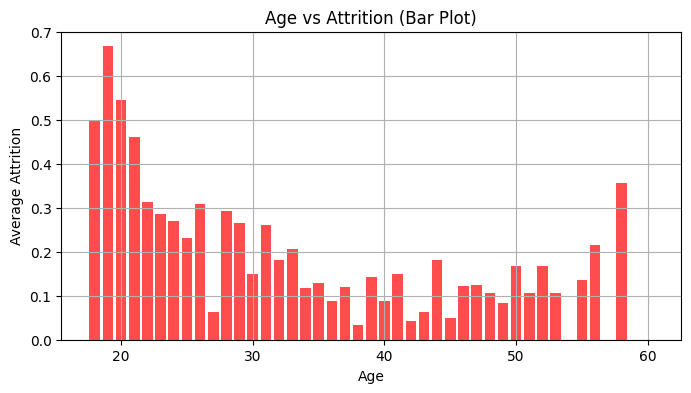

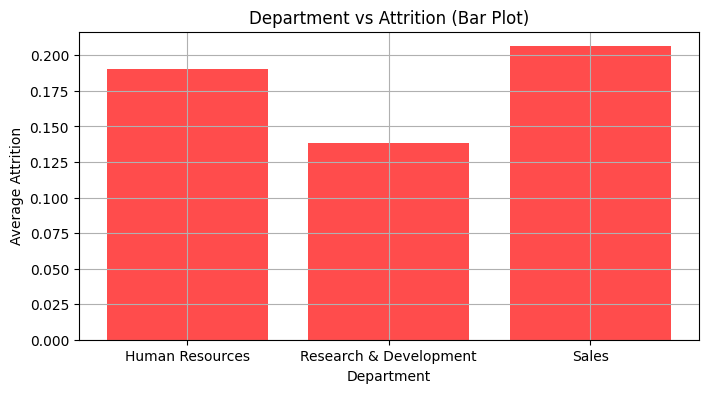

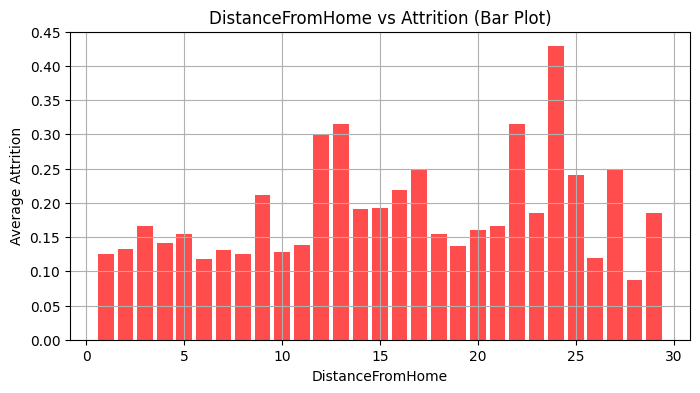

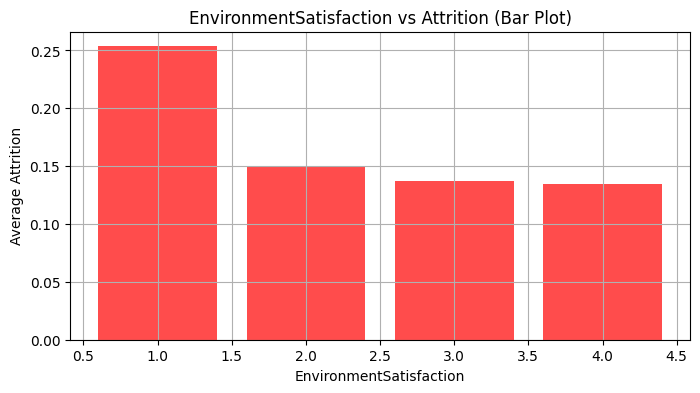

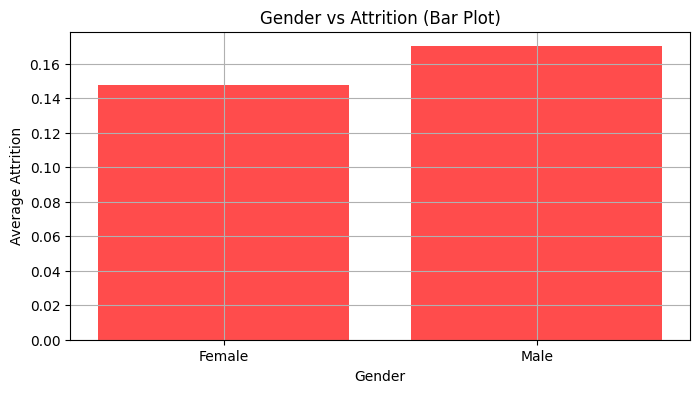

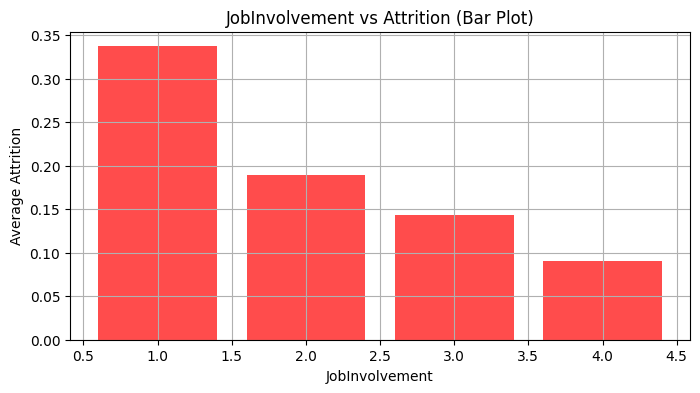

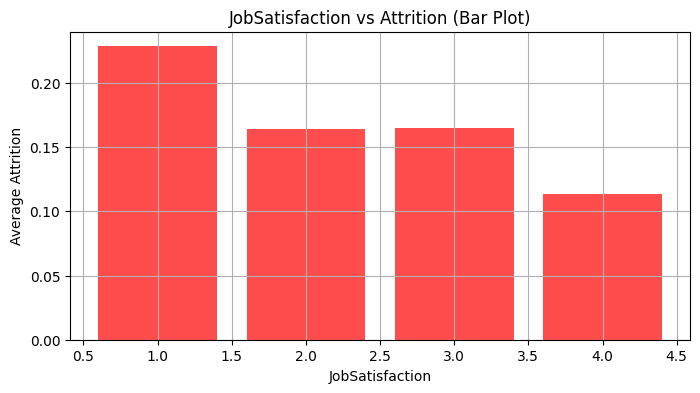

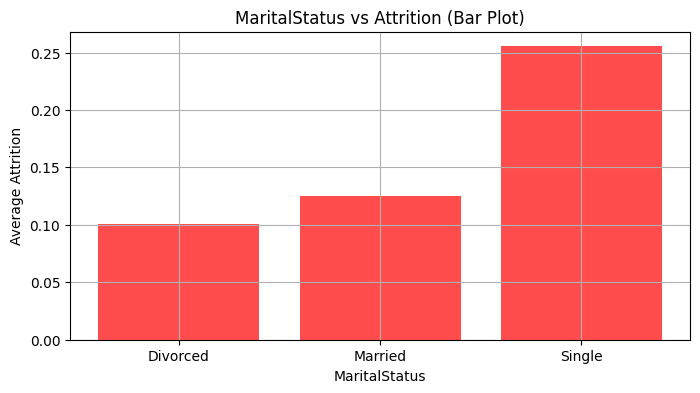

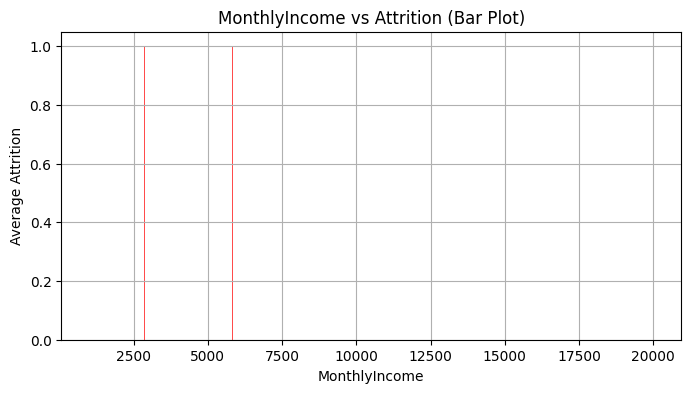

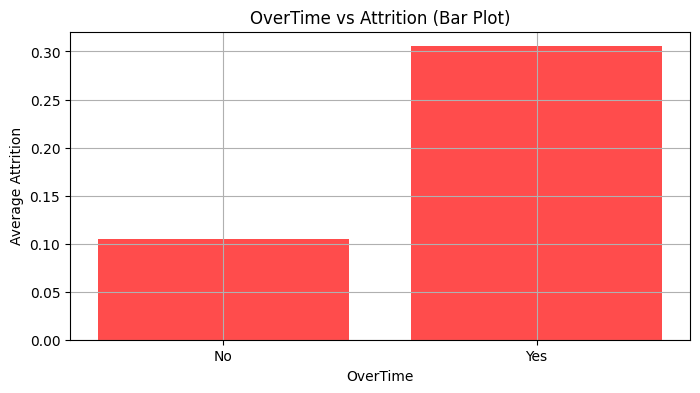

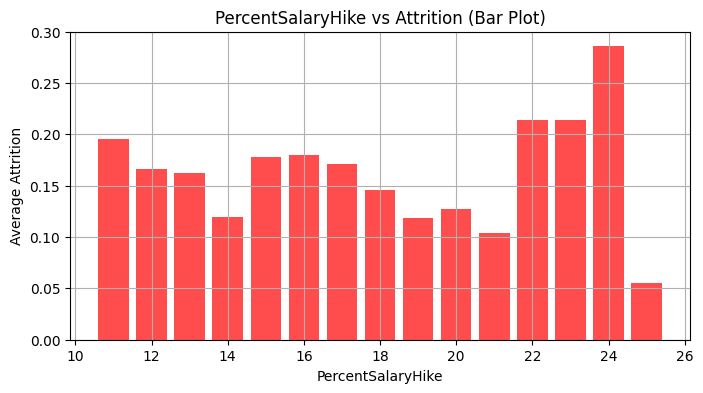

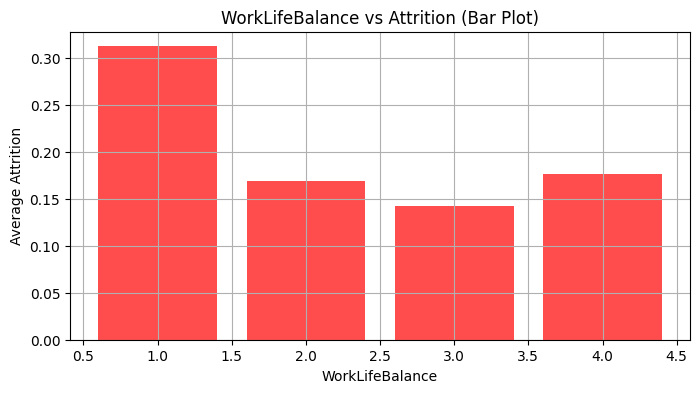

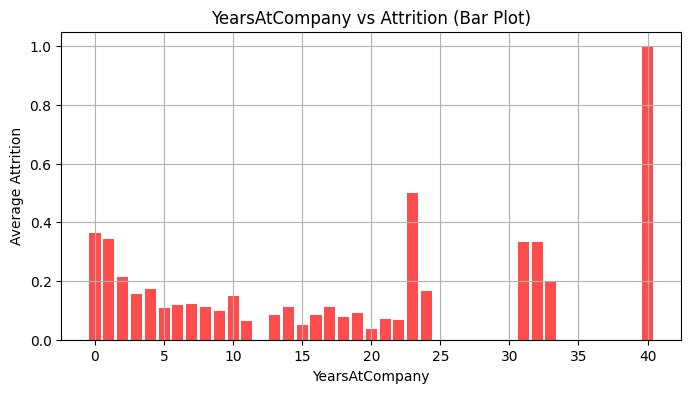

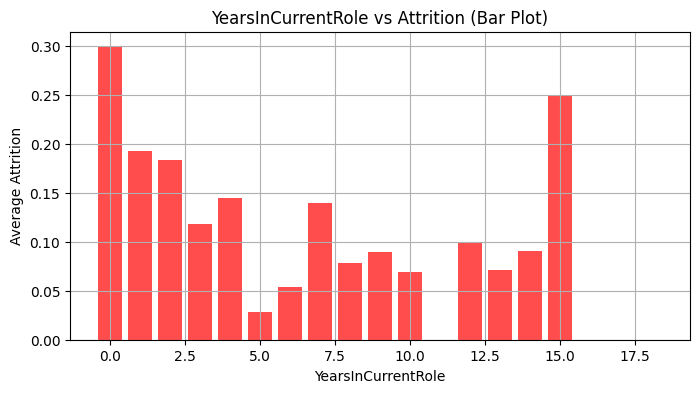

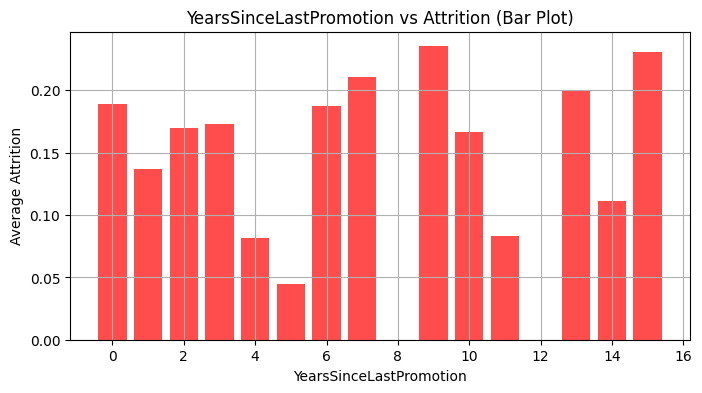

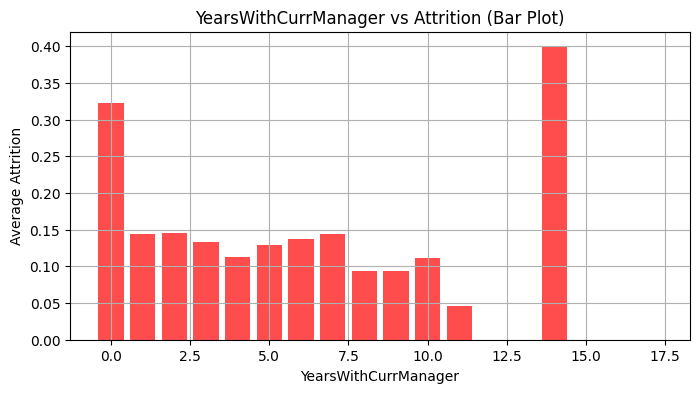

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

df_plots = employee_df.toPandas()
df_plots["Attrition"] = df_plots["Attrition"].map({"Yes": 1, "No": 0})

independent_variables_plot = [
    "Age", "Department", "DistanceFromHome", "EnvironmentSatisfaction", 
    "Gender", "JobInvolvement", "JobSatisfaction", "MaritalStatus", 
    "MonthlyIncome", "OverTime", "PercentSalaryHike", "WorkLifeBalance", 
    "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion", 
    "YearsWithCurrManager"
]
for column in independent_variables_plot:
    plt.figure(figsize=(8, 4))
    if df_plots[column].dtype in ['int64', 'float64']:
        plt.scatter(df_plots[column], df_plots["Attrition"], alpha=0.7, color="blue")
        plt.title(f"{column} vs Attrition (Scatter Plot)")
        plt.xlabel(column)
        plt.ylabel("Attrition")
    else:
        grouped_data_plot = df_plots.groupby(column)["Attrition"].mean()
        plt.bar(grouped_data_plot.index, grouped_data_plot.values, color="red", alpha=0.7)
        plt.title(f"{column} vs Attrition (Bar Plot)")
        plt.xlabel(column)
        plt.ylabel("Average Attrition")
    
    plt.grid()
    plt.show()
